# Những thư viện sử dụng cho việc Tiền xử lí dữ liệu dạng Bảng:

- Chạy đoạn code bên dưới nếu chưa tải những thư viện cần thiết

In [1]:
%pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Khai báo những thư viện cần thiết

In [19]:
import shutil
import os
import kagglehub
import pandas as pd
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## I. Tải xuống bộ dữ liệu:

Trong bước này, chúng em tải bộ dữ liệu đã chọn trực tiếp từ **Kaggle** bằng thư viện `kagglehub`. Sau khi tải xuống, toàn bộ các tệp dữ liệu sẽ được sao chép vào cấu trúc thư mục dự án đã được định nghĩa trước (`data/tabular/`). 

In [3]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Đường dẫn đến tập dữ liệu:", path)

destination = "../data/tabular"
os.makedirs(destination, exist_ok=True)

moved = 0

for root, _, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            src = os.path.join(root, file)
            dst = os.path.join(destination, file)

            shutil.copy2(src, dst)
            moved += 1
            print(f"Đã sao chép: {file}")

print(f"Đã di chuyển {moved} tệp đến {destination}")

Đường dẫn đến tập dữ liệu: C:\Users\AnhTris\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3
Đã sao chép: creditcard.csv
Đã di chuyển 1 tệp đến ../data/tabular



After downloading and organizing the dataset, the following file is available in the `data/tabular/` directory:

```
data/tabular/
└── creditcard.csv
```

This file contains the **Credit Card Fraud Detection dataset**, which is used for exploratory data analysis, preprocessing, and building classification models to detect fraudulent credit card transactions.

* Represents **real-world credit card transactions** made by European cardholders over **two consecutive days** in September 2013.
* Highly **imbalanced dataset**, with **492 fraudulent transactions** out of **284,807 total transactions** (≈ **0.172% fraud rate**).
* Designed specifically for **fraud detection and anomaly detection tasks**, where standard accuracy metrics are insufficient.

The dataset includes the following types of features:

* **Anonymized transaction features** (`V1`–`V28`):

  * Numerical features obtained via **Principal Component Analysis (PCA)** to protect sensitive customer information.
  * Capture underlying transaction patterns without revealing original attributes.
* **Non-PCA features**:

  * `Time`: Seconds elapsed between each transaction and the first transaction in the dataset.
  * `Amount`: Transaction amount, useful for **cost-sensitive learning**.
* **Target variable**:

  * `Class`: Binary label indicating transaction type

    * `1` → Fraudulent transaction
    * `0` → Legitimate transaction

**Dataset source:** Kaggle – [*Credit Card Fraud Detection*](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


## II. Loading the datasets

In [4]:
destination = "../data/tabular"
data = pd.read_csv(os.path.join(destination, "creditcard.csv"))

### Một số thông tin cơ bản của tập dữ liệu

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### III. Xử lí những phần dữ liệu bị thiếu: 

- Tìm tất cả các cột có dữ liệu bị thiếu

In [6]:
# Print out the table, including columns' name, data type and missing counts

missing_columns = data.columns[data.isnull().any()]
missing_info = []
for col in missing_columns:
    missing_count = data[col].isnull().sum()
    missing_pct = (missing_count / len(data)) * 100
    dtype = data[col].dtype
    
    missing_info.append({
        'Cột': col,
        'Kiểu dữ liệu': dtype,
        'Số lượng thiếu': missing_count,
        'Tỷ lệ thiếu %': f"{missing_pct:.2f}%"
    })

# Create DataFrame for better visualization
missing_df = pd.DataFrame(missing_info)
print(f"\nTổng số cột có giá trị thiếu: {len(missing_columns)}")
print(f"Tổng số cột trong tập dữ liệu: {len(data.columns)}\n")
print(missing_df.to_string(index=False))

print("\n" + "="*60)


Tổng số cột có giá trị thiếu: 0
Tổng số cột trong tập dữ liệu: 31

Empty DataFrame
Columns: []
Index: []



&rarr; Vì tập dữ liệu chúng ta không bị thiếu nên ta sẽ không cần xử lí việc thiếu dữ liệu

### IV. Data Normalization:

- Trong tập dữ liệu này, các đặc trưng `V1 - V28` đã được chuẩn hóa nên ta sẽ không xét đến chúng

In [7]:
# Get numerical columns from the final imputed dataset except from the target column 'Class' and from V1 to V28
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['Class'] + [f'V{i}' for i in range(1, 29)]]

- Kiểm tra các giá trị ngoại lai trong tập dữ liệu

In [8]:
print(f"\nSố cột số để chuẩn hóa: {len(numerical_cols)}")
print(f"Các cột: {numerical_cols}")

# Check for outliers before normalization
print("\n" + "-"*60)
print("Phát hiện ngoại lệ trước khi chuẩn hóa:")
print("-"*60)

outlier_summary = {}
for col in numerical_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(data)) * 100
    
    outlier_summary[col] = outlier_count
    print(f"{col}: {outlier_count} giá trị ngoại lai ({outlier_pct:.2f}%)")


Số cột số để chuẩn hóa: 2
Các cột: ['Time', 'Amount']

------------------------------------------------------------
Phát hiện ngoại lệ trước khi chuẩn hóa:
------------------------------------------------------------
Time: 0 giá trị ngoại lai (0.00%)
Amount: 31904 giá trị ngoại lai (11.20%)


- Sử dụng các phương pháp khác nhau trong việc chuẩn hóa để xem những kết quả chuẩn hóa

In [9]:
# Create copies for different normalization techniques
data_minmax = data.copy()
data_standard = data.copy()
data_robust = data.copy()

# Initialize scalers
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


data_minmax[numerical_cols] = minmax_scaler.fit_transform(data[numerical_cols])
data_standard[numerical_cols] = standard_scaler.fit_transform(data[numerical_cols])
data_robust[numerical_cols] = robust_scaler.fit_transform(data[numerical_cols])

In [10]:
# Statistical comparison
print("\n" + "="*60)
print("So sánh thống kê giữa các phương pháp chuẩn hóa:")
print("="*60)

for col in numerical_cols:
    print(f"\nCột: {col}")
    stats = pd.DataFrame({
        'Phương pháp': ['Gốc', 'Min-Max', 'Chuẩn hóa', 'Robust'],
        'Trung bình': [
            data[col].mean(),
            data_minmax[col].mean(),
            data_standard[col].mean(),
            data_robust[col].mean()
        ],
        'Độ lệch chuẩn': [
            data[col].std(),
            data_minmax[col].std(),
            data_standard[col].std(),
            data_robust[col].std()
        ],
        'Giá trị nhỏ nhất': [
            data[col].min(),
            data_minmax[col].min(),
            data_standard[col].min(),
            data_robust[col].min()
        ],
        'Giá trị lớn nhất': [
            data[col].max(),
            data_minmax[col].max(),
            data_standard[col].max(),
            data_robust[col].max()
        ]
    })
    print(stats.to_string(index=False))


So sánh thống kê giữa các phương pháp chuẩn hóa:

Cột: Time
Phương pháp    Trung bình  Độ lệch chuẩn  Giá trị nhỏ nhất  Giá trị lớn nhất
        Gốc  9.481386e+04   47488.145955          0.000000     172792.000000
    Min-Max  5.487167e-01       0.274828          0.000000          1.000000
  Chuẩn hóa -3.065637e-16       1.000002         -1.996583          1.642058
     Robust  1.189142e-01       0.557903         -0.994983          1.035022

Cột: Amount
Phương pháp   Trung bình  Độ lệch chuẩn  Giá trị nhỏ nhất  Giá trị lớn nhất
        Gốc 8.834962e+01     250.120109          0.000000      25691.160000
    Min-Max 3.438911e-03       0.009736          0.000000          1.000000
  Chuẩn hóa 2.913952e-17       1.000002         -0.353229        102.362243
     Robust 9.271239e-01       3.495006         -0.307413        358.683155


- Phân phối trước và sau khi được chuẩn hóa.

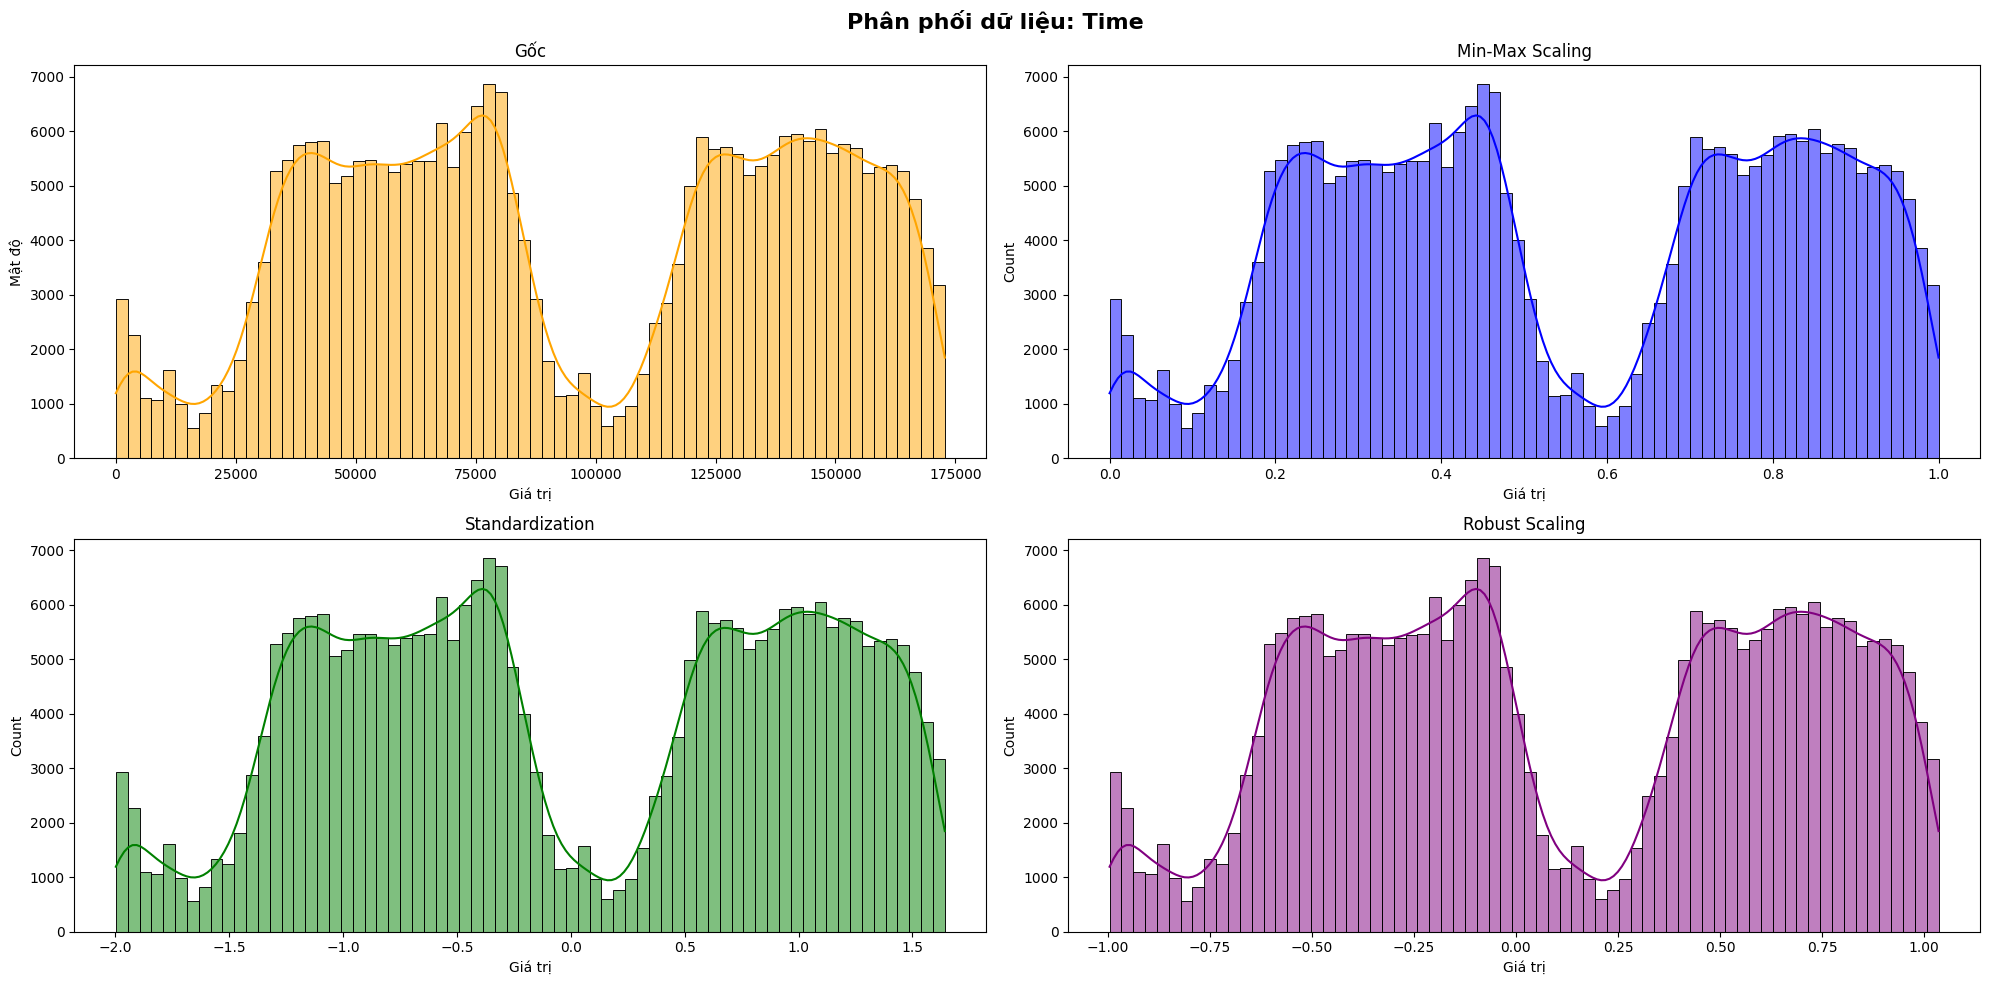

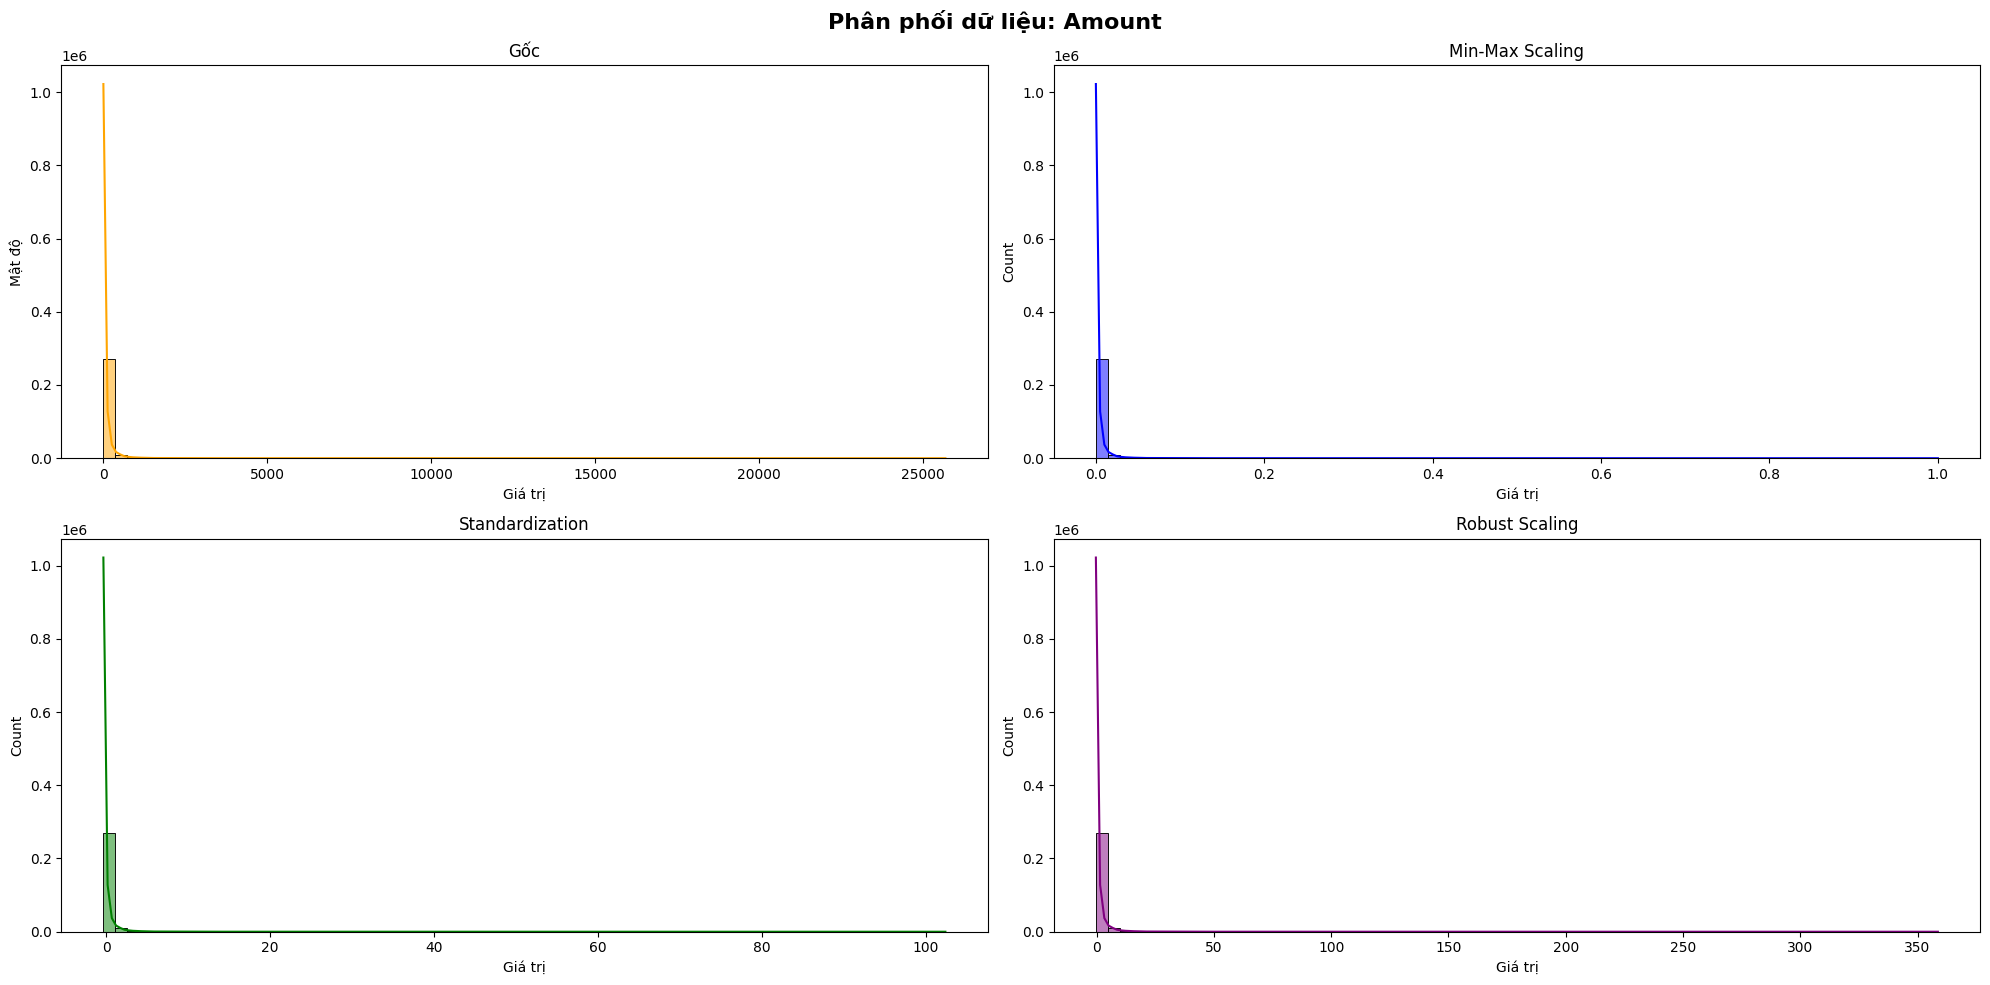

In [11]:
# Visualize distributions before and after normalization
for col in numerical_cols:
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    fig.suptitle(f'Phân phối dữ liệu: {col}', fontsize=16, fontweight='bold')

    # Original
    sns.histplot(
        data[col],
        bins=70,
        kde=True,
        ax=axes[0, 0],
        color='orange'
    )
    axes[0, 0].set_title('Gốc')
    axes[0, 0].set_xlabel('Giá trị')
    axes[0, 0].set_ylabel('Mật độ')

    # Min-Max Scaling
    sns.histplot(
        data_minmax[col],
        bins=70,
        kde=True,
        ax=axes[0, 1],
        color='blue'
    )
    axes[0, 1].set_title('Min-Max Scaling')
    axes[0, 1].set_xlabel('Giá trị')

    # Standardization
    sns.histplot(
        data_standard[col],
        bins=70,
        kde=True,
        ax=axes[1, 0],
        color='green'
    )
    axes[1, 0].set_title('Standardization')
    axes[1, 0].set_xlabel('Giá trị')

    # Robust Scaling
    sns.histplot(
        data_robust[col],
        bins=70,
        kde=True,
        ax=axes[1, 1],
        color='purple'
    )
    axes[1, 1].set_title('Robust Scaling')
    axes[1, 1].set_xlabel('Giá trị')

    plt.tight_layout()
    plt.show()


In [12]:
# Analyze which is best based on outlier count
total_outliers = sum(outlier_summary.values())
outlier_percentage = (total_outliers / (len(data) * len(numerical_cols))) * 100

if outlier_percentage > 10:
    print(f"  → Nên sử dụng ROBUST SCALING ({outlier_percentage:.1f}% để kiểm tra các giá trị ngoại lai)")
    print("    Dữ liệu của bạn có nhiều giá trị ngoại lai đáng kể có thể làm sai lệch Min-Max và chuẩn hóa")
    data_normalized = data_robust.copy()
    scaler_used = "Robust Scaling"
elif outlier_percentage > 5:
    print(f"  → Nên sử dụng STANDARDIZATION ({outlier_percentage:.1f}% để kiểm tra các giá trị ngoại lai)")
    print("    Có giá trị ngoại lai vừa phải; chuẩn hóa cân bằng giữa độ bền và hiệu suất")
    data_normalized = data_standard.copy()
    scaler_used = "Standardization"
else:
    print(f"  → Nên sử dụng MIN-MAX SCALING ({outlier_percentage:.1f}% để kiểm tra các giá trị ngoại lai)")
    print("    Ít giá trị ngoại lai; Min-Max scaling cung cấp phạm vi giới hạn [0,1] cho các thuật toán")
    data_normalized = data_minmax.copy()
    scaler_used = "Min-Max Scaling"

print(f"\n✓ Kỹ thuật đã sử dụng: {scaler_used}")
print(f"  Tổng số hàng: {len(data_normalized)}")
print(f"  Cột đã chuẩn hóa: {len(numerical_cols)}")

  → Nên sử dụng STANDARDIZATION (5.6% để kiểm tra các giá trị ngoại lai)
    Có giá trị ngoại lai vừa phải; chuẩn hóa cân bằng giữa độ bền và hiệu suất

✓ Kỹ thuật đã sử dụng: Standardization
  Tổng số hàng: 284807
  Cột đã chuẩn hóa: 2


### V. Categorical Encoding: 

- Lấy ra các giá trị định danh

In [13]:
# Get categorical columns from the normalized dataset
categorical_cols = data_normalized.select_dtypes(include=['object']).columns.tolist()

print(f"\nCác cột định danh: {len(categorical_cols)}")
print(f"Các cột: {categorical_cols}")


Các cột định danh: 0
Các cột: []


&rarr; Vì không có cột định danh nên ta sẽ không thực hiện việc chuẩn hóa

### VI. Feature Selection: 

In [14]:
# Get all numerical features from encoded dataset
all_features = data_normalized.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()

print(f"\nTổng số đặc trưng: {len(all_features)}")
print(f"Kích thước bộ dữ liệu: {data_normalized.shape}")


Tổng số đặc trưng: 31
Kích thước bộ dữ liệu: (284807, 31)


&rarr; Thử những phương pháp khác nhau để chọn lọc những đặc trưng quan trọng.


Phương pháp 1: Tương quan với biến mục tiêu (Class)


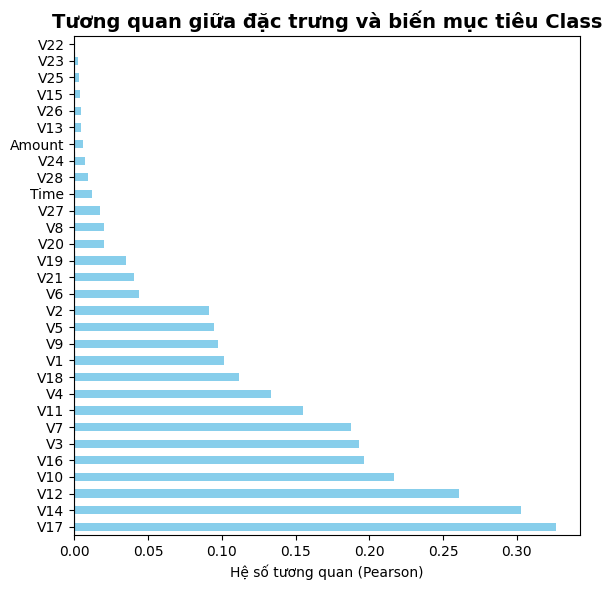

In [15]:
# Method 1: CORRELATION WITH TARGET (Class)
print("\n" + "="*60)
print("Phương pháp 1: Tương quan với biến mục tiêu (Class)")
print("="*60)

# Compute correlation with target
corr_with_target = data_normalized[all_features].corr()['Class'].abs().sort_values(ascending=False)
corr_with_target.drop('Class', inplace=True)

# Trực quan hệ số tương quan của tất cả đặc trưng với biến mục tiêu
plt.figure(figsize=(6, 6))
corr_with_target.plot(
    kind='barh',
    color = 'skyblue'
)
plt.axvline(0, linestyle='--')
plt.title('Tương quan giữa đặc trưng và biến mục tiêu Class', fontsize=14, fontweight='bold')
plt.xlabel('Hệ số tương quan (Pearson)')
plt.tight_layout()
plt.show()


In [16]:
# Take absolute value for thresholding
corr_abs = corr_with_target.abs()

# Threshold
corr_threshold = 0.2

# Select features based on correlation threshold
features_after_corr = corr_abs[corr_abs >= corr_threshold].index.tolist()

# Print results
print(f"\n✓ Ngưỡng tương quan |corr| ≥ {corr_threshold}")
print(f"✓ Số đặc trưng được giữ lại: {len(features_after_corr)} / {len(all_features)}")
print("\nDanh sách đặc trưng được chọn:")
for f in features_after_corr:
    print(f"  {f}: corr = {corr_with_target[f]:.3f}")


✓ Ngưỡng tương quan |corr| ≥ 0.2
✓ Số đặc trưng được giữ lại: 4 / 31

Danh sách đặc trưng được chọn:
  V17: corr = 0.326
  V14: corr = 0.303
  V12: corr = 0.261
  V10: corr = 0.217


In [17]:
# Method 2: VARIANCE THRESHOLD
print("\n" + "="*60)
print("Phương pháp 2: Ngưỡng phương sai")
print("="*60)

variance_threshold = 0.01  # Remove features with variance < 0.01

# Tách feature và target cho chắc chắn
features_without_target = [f for f in all_features if f != 'Class']

# Khởi tạo VarianceThreshold
var_selector = VarianceThreshold(threshold=variance_threshold)

# Fit trên feature ONLY (không có Class)
var_selector.fit(data_normalized[features_without_target])

# Mask các feature được giữ lại
var_mask = var_selector.get_support()

# Danh sách feature sau khi lọc
features_after_variance = [
    f for f, selected in zip(features_without_target, var_mask) if selected
]

# In kết quả
print(f"\nNgưỡng phương sai: {variance_threshold}")
print(f"✓ Đặc trưng có phương sai đủ lớn: {len(features_after_variance)}")
print(features_after_variance)

print(
    f"✓ Đặc trưng có phương sai thấp bị loại bỏ: "
    f"{len(features_without_target) - len(features_after_variance)}"
)



Phương pháp 2: Ngưỡng phương sai

Ngưỡng phương sai: 0.01
✓ Đặc trưng có phương sai đủ lớn: 30
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
✓ Đặc trưng có phương sai thấp bị loại bỏ: 0



Phương pháp 3: Độ quan trọng của đặc trưng (Random Forest)

Độ quan trọng của các đặc trưng:
V14       0.175555
V10       0.112880
V4        0.112270
V12       0.101297
V17       0.088148
V3        0.061046
V11       0.057901
V16       0.055982
V2        0.029452
V7        0.021061
V21       0.018469
V9        0.018443
V19       0.013146
Amount    0.012287
V27       0.011180
V18       0.010222
V8        0.010044
V20       0.009811
V1        0.008876
V26       0.008310
V5        0.008273
V13       0.008142
V6        0.006631
V23       0.006604
V28       0.006381
V15       0.006378
V22       0.006226
V25       0.005917
Time      0.004772
V24       0.004297
dtype: float64


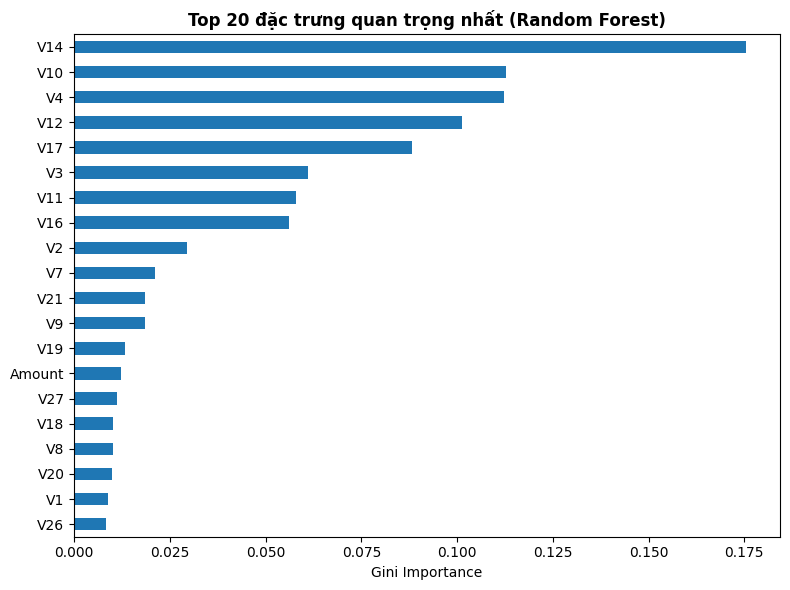


✓ Top 20 đặc trưng được chọn:
['V14', 'V10', 'V4', 'V12', 'V17', 'V3', 'V11', 'V16', 'V2', 'V7', 'V21', 'V9', 'V19', 'Amount', 'V27', 'V18', 'V8', 'V20', 'V1', 'V26']


In [20]:
# Method 3: FEATURE IMPORTANCE (Random Forest)
print("\n" + "="*60)
print("Phương pháp 3: Độ quan trọng của đặc trưng (Random Forest)")
print("="*60)

# Xác định biến mục tiêu
target_col = 'Class'

# Tách feature và target
feature_cols = [f for f in all_features if f != target_col]

X = data_normalized[feature_cols]
y = data_normalized[target_col]

# Huấn luyện Random Forest Classifier (xử lý imbalance)
model_RandomForest = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_RandomForest.fit(X, y)

# Feature importance
feature_importances = pd.Series(
    model_RandomForest.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nĐộ quan trọng của các đặc trưng:")
print(feature_importances)

# Visualization: Top 16 features
top_k = 20
plt.figure(figsize=(8, 6))
feature_importances.head(top_k).plot(
    kind='barh'
)
plt.gca().invert_yaxis()
plt.xlabel('Gini Importance')
plt.title(f'Top {top_k} đặc trưng quan trọng nhất (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

# Selected features
features_after_importance = feature_importances.head(top_k).index.tolist()
print(f"\n✓ Top {top_k} đặc trưng được chọn:")
print(features_after_importance)

In [21]:
# Method 4: RECURSIVE FEATURE ELIMINATION (RFE)
print("\n" + "="*60)
print("Phương pháp 4: Loại bỏ đặc trưng đệ quy (RFE)")
print("="*60)

# Xác định biến mục tiêu
target_col = 'Class'

# Tách feature và target
feature_cols = [f for f in all_features if f != target_col]

X_RFE = data_normalized[feature_cols]
y_RFE = data_normalized[target_col]

# Số đặc trưng cần chọn
n_features_to_select = min(20, len(feature_cols))
print(f"\nLựa chọn {n_features_to_select} đặc trưng bằng RFE...")

# Logistic Regression (phù hợp cho phân loại nhị phân)
estimator = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

# RFE
rfe = RFE(
    estimator=estimator,
    n_features_to_select=n_features_to_select,
    step=1
)

# Fit RFE
rfe.fit(X_RFE, y_RFE)

# Feature được chọn
features_after_rfe = X_RFE.columns[rfe.support_].tolist()
print(f"\n✓ Đặc trưng được chọn bởi RFE ({len(features_after_rfe)}):")
print(features_after_rfe)

# Bảng xếp hạng feature
rfe_ranking = pd.DataFrame({
    'Đặc trưng': X_RFE.columns,
    'Hạng': rfe.ranking_,
    'Được chọn': rfe.support_
}).sort_values('Hạng')

print("\nTop 20 đặc trưng theo thứ hạng RFE:")
print(rfe_ranking.head(20))



Phương pháp 4: Loại bỏ đặc trưng đệ quy (RFE)

Lựa chọn 20 đặc trưng bằng RFE...

✓ Đặc trưng được chọn bởi RFE (20):
['Time', 'V1', 'V2', 'V4', 'V5', 'V6', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V16', 'V17', 'V20', 'V22', 'V26', 'V28', 'Amount']

Top 20 đặc trưng theo thứ hạng RFE:
   Đặc trưng  Hạng  Được chọn
0       Time     1       True
1         V1     1       True
2         V2     1       True
4         V4     1       True
6         V6     1       True
5         V5     1       True
9         V9     1       True
8         V8     1       True
12       V12     1       True
13       V13     1       True
10       V10     1       True
11       V11     1       True
14       V14     1       True
22       V22     1       True
17       V17     1       True
16       V16     1       True
28       V28     1       True
29    Amount     1       True
26       V26     1       True
20       V20     1       True



             Phương pháp  Số đặc trưng được chọn  Tỷ lệ giảm (%)
           Đặc trưng gốc                      31        0.000000
             Correlation                       4       87.096774
      Variance Threshold                      30        3.225806
Random Forest Importance                      20       35.483871
                     RFE                      20       35.483871


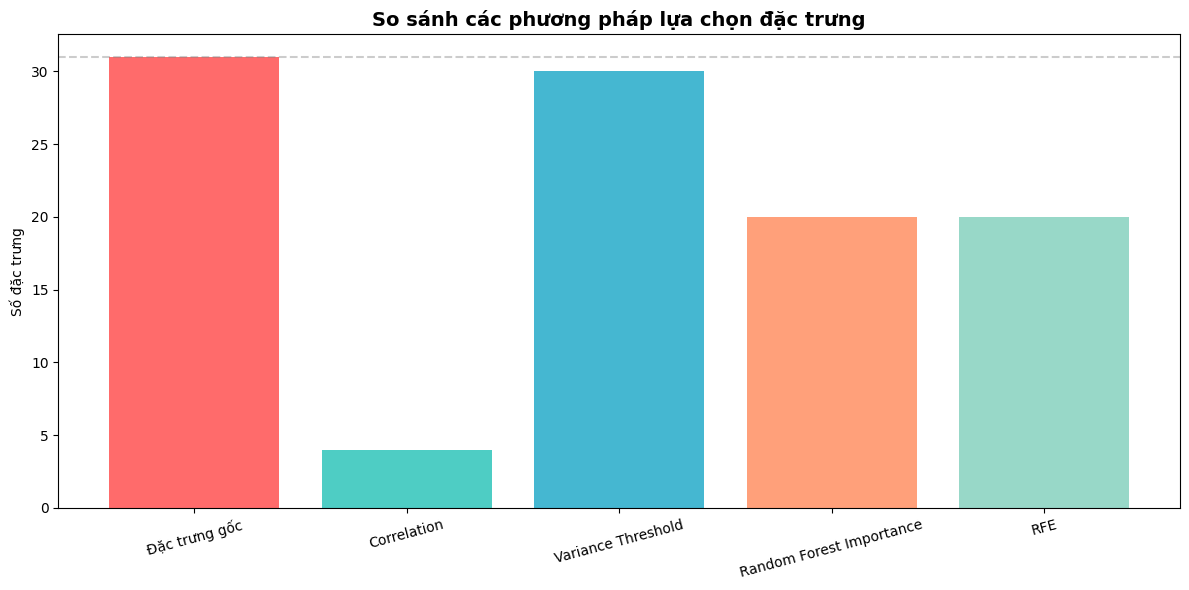


[PHÂN TÍCH GIAO NHAU]
Đặc trưng chung của TẤT CẢ phương pháp: 4
Đặc trưng được ≥ 3 phương pháp chọn: 14

[FINAL FEATURE SET]
Số đặc trưng cuối cùng: 15
Kích thước dữ liệu: (284807, 15)

Danh sách đặc trưng cuối:
1. Time
2. V1
3. V10
4. V11
5. V12
6. V13
7. V14
8. V16
9. V17
10. V2
11. V4
12. V5
13. V6
14. V8
15. V9


In [24]:

comparison = pd.DataFrame({
    'Phương pháp': [
        'Đặc trưng gốc',
        'Correlation',
        'Variance Threshold',
        'Random Forest Importance',
        'RFE'
    ],
    'Số đặc trưng được chọn': [
        len(all_features),
        len(features_after_corr),
        len(features_after_variance),
        len(features_after_importance),
        len(features_after_rfe)
    ]
})

comparison['Tỷ lệ giảm (%)'] = (
    1 - comparison['Số đặc trưng được chọn'] / len(all_features)
) * 100

print("\n" + comparison.to_string(index=False))

plt.figure(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.bar(
    comparison['Phương pháp'],
    comparison['Số đặc trưng được chọn'],
    color=colors
)
plt.axhline(len(all_features), linestyle='--', alpha=0.4, color='gray')
plt.title('So sánh các phương pháp lựa chọn đặc trưng', fontsize=14, fontweight='bold')
plt.ylabel('Số đặc trưng')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

set_corr = set(features_after_corr)
set_var = set(features_after_variance)
set_rf = set(features_after_importance)
set_rfe = set(features_after_rfe)

common_all = set_corr & set_var & set_rf & set_rfe
common_three = (
    (set_corr & set_rf & set_rfe) |
    (set_corr & set_var & set_rf) |
    (set_corr & set_var & set_rfe) |
    (set_var & set_rf & set_rfe)
)

print("\n[PHÂN TÍCH GIAO NHAU]")
print(f"Đặc trưng chung của TẤT CẢ phương pháp: {len(common_all)}")
print(f"Đặc trưng được ≥ 3 phương pháp chọn: {len(common_three)}")

# ==============================
# 8. FINAL FEATURE SET (CONSENSUS)
# ==============================
final_features = list(set_corr & set_rf)

if len(final_features) < 15:
    bổ_sung = [f for f in features_after_rfe if f not in final_features]
    final_features.extend(bổ_sung[:15 - len(final_features)])

data_final_selected = data_normalized[final_features]

print("\n[FINAL FEATURE SET]")
print(f"Số đặc trưng cuối cùng: {len(final_features)}")
print(f"Kích thước dữ liệu: {data_final_selected.shape}")

print("\nDanh sách đặc trưng cuối:")
for i, f in enumerate(sorted(final_features), 1):
    print(f"{i}. {f}")

